# PDB to ODE and NERDSS Workflow
## Tutorial 3 : benzaldehyde lyase mutant M6 from Herbiconiux sp. SALV-R1 (8y7s)

This tutorial demonstrates 8y7s as an example to use ProAffinity-GNN(1) to predict binding affinities. Note that for detailed explanation of the workflow, refer to tutorial 1: `ionerdss_tutorial_6bno.ipynb`

> ### Aims for this tutorial:
> - Give an example of a homo-tetramer assembly but has three different types of symmetric bindings
> - Tutorial on how to install and use ProAffinity-GNN to predict binding affinities

## Example: 8Y7S Structure

- In this file, we'll use **8Y7S** homotetramer assembly as our example.

---
## Part 1: Preparation - Install Dependencies

ProAffinity-GNN(1) depends on PyTorch and AutoDockFR (ADFR)(2,3). The installation is specific to the hardware, conda/pip/wheel, the CUDA version, and the operating system. Therefore, we keep PyTorch and ADFR out of the default dependency files and the users need to install them separately.

### 1.1. Set up the ProAffinity environment (PyTorch v2.2.2)

ProAffinity-GNN requires `numpy` < 2.0.0, which cannot coexist with the `numpy` >= 2 that OVITO rendering needs. Rather than force one environment to satisfy both, ProAffinity gets an environment of its own, and ioNERDSS calls into it when it needs a binding energy. Only a PDB path, the chain pairs, and the resulting energies cross between the two, so the dependency stacks never meet.

Create it once, from the root of an ioNERDSS checkout:

```
conda env create -f env/proaffinity/environment.yml
export IONERDSS_PROAFFINITY_PYTHON="$(conda info --base)/envs/ionerdss-proaffinity/bin/python"
```

Without a checkout:

```
conda create -y -n ionerdss-proaffinity python=3.10
conda run -n ionerdss-proaffinity pip install "ioNERDSS[proaffinity]"
export IONERDSS_PROAFFINITY_PYTHON="$(conda info --base)/envs/ionerdss-proaffinity/bin/python"
```

Add that `export` to your shell profile so it persists, then restart this kernel so the notebook picks it up. **You do not activate that environment to run this tutorial** -- keep working in your usual ioNERDSS environment, and everything below works unchanged.

> **Note:** The ProAffinity-GNN is written and tested with pyTorch v2.2.2, though later versions may also work. Python is pinned to 3.10 above because torch 2.2.2 publishes wheels for CPython 3.8-3.12 only.

> **Note:** If you would rather keep everything in one environment, `pip install "ioNERDSS[proaffinity]"` still works and prediction runs in-process. Be aware that this pins `numpy` below 2.0.0 for that environment, which holds OVITO back to a version that cannot render animations -- see `docs/Proaffinity.md`.

### 1.2. Install ADFR

#### Linux

Visit the following website and install based on your environment:

https://ccsb.scripps.edu/adfr/downloads/

#### MacOS

If you are using macOS, the macOS safety feature may prevent the installation. You can install with the provided install script `install_ADFR_mac.sh` (Only works for macOS). You might need to give it permission to run first:

```
chmod +x install_ADFR_mac.sh
```

Then run:

```
./install_ADFR_mac.sh
```

> **Note:** ADFRsuite provides a fully fledged Python interpreter (v2.7) that will be installed in the ADFRsuite-1.0 folder. This Python interpreter is insulated from, and will not interfere with, the default python interpreter on your computer. It can be invoked using ADFRsuite-1.0/bin/pythonsh.

> **WARNING:** DO NOT add `ADFRsuite-1.0` or `ADFRsuite-1.0/bin` to your system `PATH` variable. Otherwise, commandline `python` may  call this `python2.7`.

> **Note:** ADFR is invoked by the ProAffinity environment from step 1.1, not by this notebook's environment. Both run on the same machine, so the `adfr_path` you pass below just has to be readable there.




In [4]:
#Find out what is loaded within this Jupyter Notebook kernel. This can be useful for debugging and understanding the environment.
import sys
# Filter out hidden/internal Python modules to see clean names
imported_modules = sorted([mod for mod in sys.modules if not mod.startswith('_')])
print(imported_modules)


['81d243bd2c585b0f4821__mypyc', 'Bio', 'Bio.Align', 'Bio.Align._aligncore', 'Bio.Align._alignmentcounts', 'Bio.Align._codonaligner', 'Bio.Align._pairwisealigner', 'Bio.Align.substitution_matrices', 'Bio.Align.substitution_matrices._arraycore', 'Bio.Data', 'Bio.Data.CodonTable', 'Bio.Data.IUPACData', 'Bio.Data.PDBData', 'Bio.File', 'Bio.PDB', 'Bio.PDB.AbstractPropertyMap', 'Bio.PDB.Atom', 'Bio.PDB.Chain', 'Bio.PDB.DSSP', 'Bio.PDB.Dice', 'Bio.PDB.Entity', 'Bio.PDB.FragmentMapper', 'Bio.PDB.HSExposure', 'Bio.PDB.MMCIF2Dict', 'Bio.PDB.MMCIFParser', 'Bio.PDB.Model', 'Bio.PDB.NeighborSearch', 'Bio.PDB.PDBExceptions', 'Bio.PDB.PDBIO', 'Bio.PDB.PDBList', 'Bio.PDB.PDBMLParser', 'Bio.PDB.PDBParser', 'Bio.PDB.Polypeptide', 'Bio.PDB.Residue', 'Bio.PDB.ResidueDepth', 'Bio.PDB.SASA', 'Bio.PDB.Selection', 'Bio.PDB.Structure', 'Bio.PDB.StructureAlignment', 'Bio.PDB.StructureBuilder', 'Bio.PDB.Superimposer', 'Bio.PDB.ccealign', 'Bio.PDB.cealign', 'Bio.PDB.ic_data', 'Bio.PDB.internal_coords', 'Bio.PDB.k

---
## Part 2: Run the ionerdss pipeline 

Same as in the previous tutorial, we set up and run the ionerdss pipeline. Note that we turn on ProAffinity-GNN prediction by giving the `predict_affinity=True` flag and providing the `adfr_path`.

> **WARNING!** The following block takes 10 - 30 minutes to run depending on your hardware!

> **WARNING!** Enabling ProAffinity-GNN can be heavily time- and memory-consuming. 

In [1]:
#  Path handling (standard library)
from pathlib import Path

# Core imports
import ionerdss as ion
from ionerdss import build_system_from_pdb

# For visualizations
import pandas as pd
import matplotlib.pyplot as plt

pdb_id = "8y7s"

# Build the system using simplified API
# This should take ~5 seconds for 8y7s
system = build_system_from_pdb(
    source=pdb_id,
    workspace_path=f"{pdb_id}_dir",
    interface_detect_distance_cutoff=1.5,
    interface_detect_n_residue_cutoff=5,
    chain_grouping_seq_threshold=0.5,

    # nerdss
    nerdss_total_molecule_count = 40,
    nerdss_n_itr = 100000,
    nerdss_water_box=[188, 188, 188], # = 10 uM

    # ProAffinity
    predict_affinity=True,  # Enable affinity prediction
    adfr_path='~/Documents/ADFR',  # Path to ADFR
    # proaffinity_python='...',  # Optional: the ProAffinity environment's python,
                                 # overriding $IONERDSS_PROAFFINITY_PYTHON
    
    # ODE Pipeline Configuration
    ode_enabled=True,            # Now using System-compatible generator!
    ode_time_span=None,   # Auto-calculated based on NERDSS simulation time
    ode_solver_method="BDF",     # Solver for stiff systems
    ode_plot=True,               # Generate plots
    ode_save_csv=True            # Save data to CSV
)

# (Optional) List out generated files
# List all generated files
workspace_path = Path(f"{pdb_id}_dir")

print("Generated Files:")

print("\n NERDSS Input Files:")
nerdss_dir = workspace_path / "nerdss_files"
if nerdss_dir.exists():
    for file in sorted(nerdss_dir.glob("*.mol")) + sorted(nerdss_dir.glob("*.inp")):
        size = file.stat().st_size / 1024  # KB
        print(f"  nerdss_files/{file.name:<30} ({size:>6.1f} KB)")

print("\n System Data:")
outputs_dir = workspace_path / "outputs" / "systems"
if outputs_dir.exists():
    for file in sorted(outputs_dir.glob("*.json")):
        size = file.stat().st_size / 1024  # KB
        print(f"  outputs/systems/{file.name:<27} ({size:>6.1f} KB)")

print("\n System Builder Log:")
outputs_dir = workspace_path / "logs"
if outputs_dir.exists():
    for file in sorted(outputs_dir.glob("*.log")):
        size = file.stat().st_size / 1024  # KB
        print(f"  logs/{file.name:<38} ({size:>6.1f} KB)") 

Loading ESM2 model (this will be reused for all predictions)...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Prediction 1/6: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/structures/downloaded/8y7s-assembly1.cif chains A,B
Processing /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/structures/downloaded/8y7s-assembly1.cif...
Step 1: Converting to PDBQT format...
Detected CIF file: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/structures/downloaded/8y7s-assembly1.cif
Converting CIF to PDB: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/structures/downloaded/8y7s-assembly1.cif -> /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/structures/downloaded/8y7s-assembly1_converted.pdb
✓ Successfully converted to PDB format: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/structures/downloaded/8y7s-assembly1_converted.pdb
Basename of adfr_path: ADFR
Using prepare_receptor at: /Users/margaret/Documents/ADFR/bin/prepare_receptor
Filtering ATOM lines from /Use

2026-08-24 14:50:37 - ionerdss.pdb.8Y7S - WARNING - Cannot align chain E to representative A for orientation (different lengths or too short). Using default orientation.
2026-08-24 14:50:37 - ionerdss.pdb.8Y7S - WARNING - Cannot align chain F to representative A for orientation (different lengths or too short). Using default orientation.


Predicted binding energy: -36.5979 kJ/mol

Completed 6 predictions using shared ESM2 model
ODE results saved to: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/ode_results/ode_solution.csv
ODE plot saved to: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/ode_results/ode_solution.png
ODE results saved to: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/ode_results/ode_solution_simple.csv
ODE plot saved to: /Users/margaret/github/JohnsonBiophysicsLab/ionerdss/tutorials/8y7s_dir/ode_results/ode_solution_simple.png
Generated Files:

 NERDSS Input Files:
  nerdss_files/A.mol                          (   0.4 KB)
  nerdss_files/parms.inp                      (   1.3 KB)

 System Data:
  outputs/systems/8Y7S_system.json            ( 302.4 KB)

 System Builder Log:
  logs/pipeline.log                           (  48.3 KB)


In [7]:
#where is an imported module located? This can be useful for debugging and understanding the environment.
print(ion.__file__)

/Users/margaret/github/JohnsonBiophysicsLab/ionerdss/ionerdss/__init__.py


---
## Part 2: Run NERDSS Simulation

### Run NERDSS with python subprocess

> **Note**: This requires NERDSS to be installed on your system. The user also has to specify the path to the NERDSS executable.

In [9]:
# run NERDSS with subprocess
import subprocess

# Check if NERDSS is available
# nerdss_cmd should be replaced with the actual path to the NERDSS executable
nerdss_cmd = "~/github/JohnsonBiophysicsLab/NERDSS/bin/nerdss"  # Update this path as needed
nerdss_path = Path(nerdss_cmd).expanduser() # replaces tilde with appropriate user home path

if nerdss_path.exists():
    
    # Run NERDSS
    result = subprocess.run(
        f"{nerdss_cmd} -f parms.inp",
        shell=True,
        cwd=f"{pdb_id}_dir/nerdss_files",
        capture_output=True,
        text=True
    )
    
    if result.returncode == 0:
        print("✓ NERDSS simulation completed!")
        print(f"\nCheck {pdb_id}_dir/nerdss_files/ for output files")
    else:
        print("⚠ NERDSS simulation failed")
        print(result.stderr[:500])
else:
    print("⚠ NERDSS not found at:", nerdss_cmd)

✓ NERDSS simulation completed!

Check 8y7s_dir/nerdss_files/ for output files


## Part 3A: Add in a structure validation step here.
In my test for this assembly, it did not stop at tetramers, it formed 5, 6, 7, 8-mers, etc. So it exhibits over-assembly. 

A very simple test is to first look in nerdss_files/DATA/histogram_complexes_time.dat 
to see if it forms complexes of size A:5 or greater. 


---
## Part 3: Analyze NERDSS Output

After running NERDSS simulations, we can analyze the results using the `Analyzer` class.


Found 1 simulation(s)
  [0] Simulation ID: nerdss_files
(array([0.00000e+00, 9.32902e-05, 1.86580e-04, 2.79871e-04, 3.73161e-04,
       4.66451e-04, 5.59741e-04, 6.53032e-04, 7.46322e-04, 8.39612e-04,
       9.32902e-04, 1.02619e-03, 1.11948e-03, 1.21277e-03, 1.30606e-03,
       1.39935e-03, 1.49264e-03, 1.58593e-03, 1.67922e-03, 1.77251e-03,
       1.86580e-03, 1.95910e-03, 2.05239e-03, 2.14568e-03, 2.23897e-03,
       2.33226e-03, 2.42555e-03, 2.51884e-03, 2.61213e-03, 2.70542e-03,
       2.79871e-03, 2.89200e-03, 2.98529e-03, 3.07858e-03, 3.17187e-03,
       3.26516e-03, 3.35845e-03, 3.45174e-03, 3.54503e-03, 3.63832e-03,
       3.73161e-03, 3.82490e-03, 3.91819e-03, 4.01148e-03, 4.10477e-03,
       4.19806e-03, 4.29135e-03, 4.38464e-03, 4.47793e-03, 4.57122e-03,
       4.66451e-03, 4.75780e-03, 4.85109e-03, 4.94438e-03, 5.03767e-03,
       5.13096e-03, 5.22425e-03, 5.31754e-03, 5.41083e-03, 5.50412e-03,
       5.59741e-03, 5.69071e-03, 5.78400e-03, 5.87729e-03, 5.97058e-03,
       

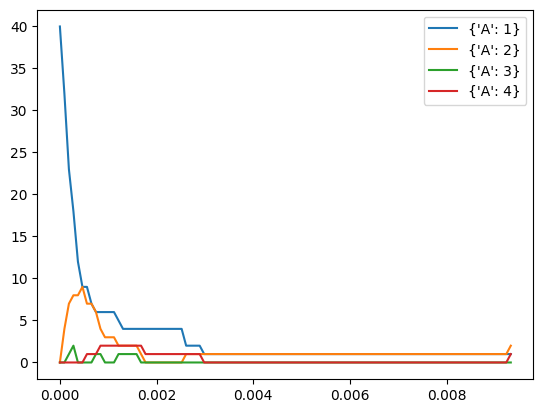

In [10]:
# Initialize Analyzer with NERDSS output directory
analysis = ion.Analyzer(f"{pdb_id}_dir")

# Display discovered simulations
print(f"Found {len(analysis.simulations)} simulation(s)")
for i, sim in enumerate(analysis.simulations):
    print(f"  [{i}] Simulation ID: {sim.id}")

#################
# Plot the NERDSS trajectory alone
plt.figure()

sim = analysis.get_simulation(0)
complex_compositions = [{"A":1},
                        {"A":2},
                        {"A":3},
                        {"A":4}] 

# get the time series data for the above complexes
time, counts = sim.get_time_series(complex_compositions)

print(sim.get_time_series(complex_compositions))

# plot all the returned data
for i in range(len(complex_compositions)):
    plt.plot(time,counts[i],label=str(complex_compositions[i]))

plt.legend()
plt.show()

---
## Summary and Next Steps

### What We've Done

 Loaded 8Y7S structure  
 Predicted the affinity of the binding site with ProAffinity-GNN  
 Exported NERDSS simulation files  
 Ran NERDSS simulation for the assembly

---

## Reference

(1) ProAffinity-GNN: A Novel Approach to Structure-Based Protein–Protein Binding Affinity Prediction via a Curated Data Set and Graph Neural Networks
Zhiyuan Zhou, Yueming Yin, Hao Han, Yiping Jia, Jun Hong Koh, Adams Wai-Kin Kong, and Yuguang Mu Journal of Chemical Information and Modeling 2024 64 (23), 8796-8808
DOI: 10.1021/acs.jcim.4c01850

(2) Pradeep Anand Ravindranath, Stefano Forli, David S. Goodsell, Arthur J. Olson, Michel F. Sanner (2015) AutoDockFR: Advances in Protein-Ligand Docking with Explicitly Specified Binding Site Flexibility. PLOS Computational Biology 11(12): e1004586. https://doi.org/10.1371/journal.pcbi.1004586

(3) Yong Zhao Daniel Stoffler Michel Sanner (2006) Hierarchical and multi-resolution representation of protein flexibility. Bioinformatics, Volume 22, Issue 22, 15 November 2006, Pages 2768–2774, https://doi.org/10.1093/bioinformatics/btl481

---

*Tutorial created: 2026-2-4*  
*IONERDSS Version: 1.2.0*